# Effect of Queue Capacity

**Research question:** How does queue capacity affect passenger waiting time, congestion, and throughput?

Compare queue capacities of 1, 2, 3 and 4 passengers per checkpoint while keeping passenger arrival probability, number of security checkpoints, and service duration fixed. Each scenario uses 30 random seeds and runs for 5,000 time steps from an initially empty system.

This experiment changes the maximum number of passengers that can wait in each checkpoint's internal queue. Passengers who cannot enter an internal queue remain in the external waiting area. Therefore, this experiment investigates whether increasing internal queue capacity reduces congestion or mainly changes where passengers wait.

## Setup

Install the project dependencies using `python -m pip install -r requirements.txt`. Select that Python environment as the notebook kernel. Run this notebook from the project root or its `notebooks` directory.

The model is imported from `src`; its implementation is not duplicated here. Restart the kernel and run all cells after changing a model file.

In [28]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = next(
    (
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "model.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Start the notebook from the project root or the notebooks directory."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

## Experimental Design

- Arrival probability: 0.4 per time step; at most one passenger arrives per step.
- Queue capacity: 1, 2, 3, and 4 waiting passengers per checkpoint, excluding passengers in service.
- Checkpoints: 2.
- Service duration: Fixed at 4 time steps.
- Processing-time variation: 0.
- Simulation length: 5,000 time steps, with no warm-up period removed.
- Seeds: 0 through 29 for each queue-capacity scenario.

The experiment changes only the queue capacity while keeping the number of checkpoints, arrival probability, service duration, and simulation length fixed. Each queue-capacity setting is repeated 30 times using seeds 0 through 29.

The same seed list is used for each queue-capacity setting to make the experiment reproducible. Since the service duration is fixed and processing-time variation is 0, changing queue capacity does not change the service rate of the checkpoints.

Completed-passenger mean waiting time is calculated only for passengers who finish screening within the observation period and includes both external and internal waiting. Internal and external queue lengths are measured separately. Throughput rate is calculated as completed passengers divided by simulation steps, and unfinished passengers are recorded at the end of each run.

In [50]:
queue_capacities = [1, 2, 3, 4]
seeds = range(30)

base_parameters = {
    "arrival_rate": 0.4,
    "num_checkpoints": 2,
    "processing_time": 4,
    "simulation_steps": 5000,
    "processing_time_variation": 0,
}

print("Queue capacities:", queue_capacities)
print("Number of repetitions:", len(seeds))

Queue capacities: [1, 2, 3, 4]
Number of repetitions: 30


In [55]:
experiment_results = []

for queue_capacity in queue_capacities:
    for seed in seeds:
        model = AirportSecurityModel(
            **base_parameters,
            queue_capacity=queue_capacity,
            seed=seed
        )
        model.run()
        results = model.get_results()
        mean_internal_queue = np.mean(model.queue_length_history)
        mean_external_queue = np.mean(model.external_waiting_history)
        mean_waiting_time = results["average_waiting_time"]
        throughput_rate = (results["throughput"] / model.simulation_steps)
        unfinished_passengers = (
            sum(len(queue) for queue in model.queues)
            + len(model.external_waiting)
            + sum(
                passenger is not None
                for passenger in model.in_service
            )
        )
        experiment_results.append({
            "queue_capacity": queue_capacity,
            "seed": seed,
            "mean_waiting_time": mean_waiting_time,
            "mean_internal_queue": mean_internal_queue,
            "mean_external_queue": mean_external_queue,
            "throughput_rate": throughput_rate,
            "unfinished_passengers": unfinished_passengers
        })

print("Experiment completed.")
print("Total runs:", len(experiment_results))

Experiment completed.
Total runs: 120


In [56]:
summary_results = []

for queue_capacity in queue_capacities:
    runs = [
        result
        for result in experiment_results
        if result["queue_capacity"] == queue_capacity
    ]
    waiting_values = np.array([
        r["mean_waiting_time"] for r in runs
    ])
    internal_values = np.array([
        r["mean_internal_queue"] for r in runs
    ])
    external_values = np.array([
        r["mean_external_queue"] for r in runs
    ])
    throughput_values = np.array([
        r["throughput_rate"] for r in runs
    ])
    unfinished_values = np.array([
        r["unfinished_passengers"] for r in runs
    ])

    valid_waiting_values = waiting_values[np.isfinite(waiting_values)]
    valid_wait_runs = len(valid_waiting_values)

    summary_results.append({
        "queue_capacity": queue_capacity,
        "valid_wait_runs": valid_wait_runs,
        "mean_waiting_time": (float(np.mean(valid_waiting_values))
                              if valid_wait_runs else np.nan),
        "sd_waiting_time": (float(np.std(valid_waiting_values, ddof=1))
                            if valid_wait_runs > 1 else np.nan),
        "mean_internal_queue": np.mean(internal_values),
        "mean_external_queue": np.mean(external_values),
        "mean_throughput_rate": np.mean(throughput_values),
        "mean_unfinished_passengers": np.mean(unfinished_values)
    })

for result in summary_results:
    print(
        f"Queue capacity: "
        f"{result['queue_capacity']}"
    )
    print(
        f"  Runs with completed passengers: "
        f"{result['valid_wait_runs']}/{len(seeds)}"
    )
    print(
        f"  Completed-passenger mean wait: "
        f"{result['mean_waiting_time']:.2f} time steps"
    )
    print(
        f"  SD of run mean waits: "
        f"{result['sd_waiting_time']:.2f} time steps"
    )
    print(
        f"  Mean internal queue: "
        f"{result['mean_internal_queue']:.2f} passengers"
    )
    print(
        f"  Mean external queue: "
        f"{result['mean_external_queue']:.2f} passengers"
    )
    print(
        f"  Mean throughput: "
        f"{result['mean_throughput_rate']:.3f} "
        f"passengers per time step"
    )
    print(
        f"  Mean unfinished passengers at end: "
        f"{result['mean_unfinished_passengers']:.2f}"
    )
    print()

Queue capacity: 1
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 1.95 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.63 passengers
  Mean external queue: 0.15 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37

Queue capacity: 2
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 1.96 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.76 passengers
  Mean external queue: 0.03 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37

Queue capacity: 3
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 1.96 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.78 passengers
  Mean external queue: 0.00 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37

Queue capacity: 4
  Runs with completed passen

## Comparison of Queue-Capacity Measures

The three panels compare the effects of queue capacity on average waiting time, mean internal queue length, mean external queue length.

All bars show means across 30 simulation runs. Only the waiting-time panel includes error bars: one standard deviation between run mean waiting times, not a confidence interval. The internal- and external-queue panels show means without error bars.

Queue capacity is varied from 1 to 4 passengers per checkpoint while the number of checkpoints, arrival probability, service duration, and simulation length are kept constant.

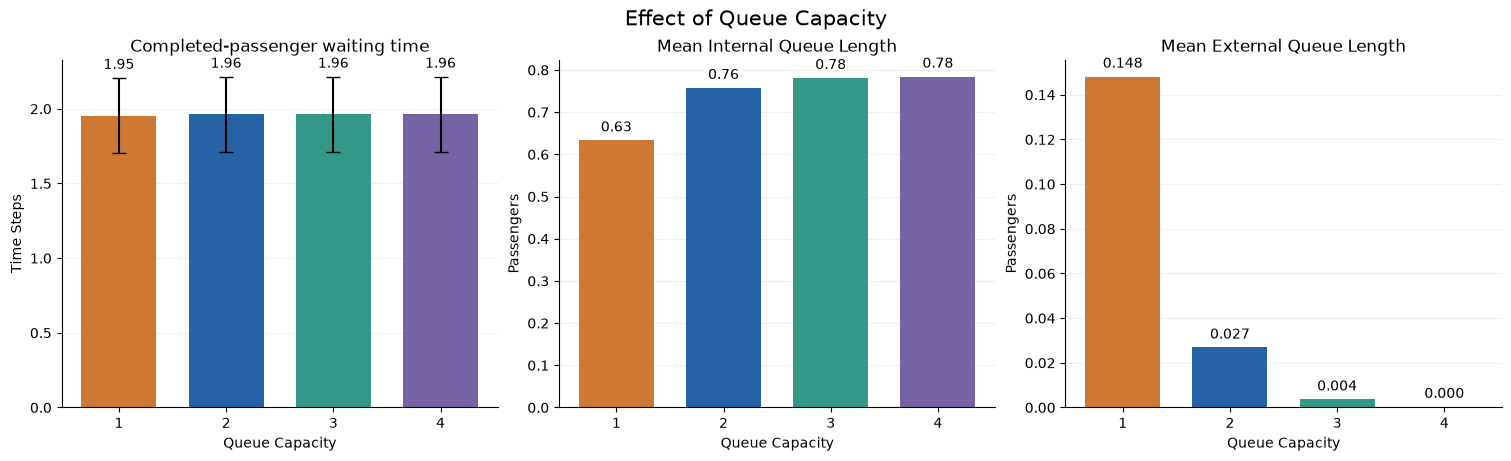

In [58]:
colors = ["#CE7833", "#2563A6", "#349889", "#7563A3"]

capacities = [
    r["queue_capacity"]
    for r in summary_results
]

x = np.arange(len(capacities))

mean_wait = np.array([
    r["mean_waiting_time"]
    for r in summary_results
])

sd_wait = np.array([
    r["sd_waiting_time"]
    for r in summary_results
])

mean_internal = np.array([
    r["mean_internal_queue"]
    for r in summary_results
])

mean_external = np.array([
    r["mean_external_queue"]
    for r in summary_results
])


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")

fig.suptitle("Effect of Queue Capacity", fontsize=15)

bars = axes[0].bar(
    x,
    mean_wait,
    yerr=sd_wait,
    capsize=5,
    width=0.7,
    color=colors
)

axes[0].bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

axes[0].set_title("Completed-passenger waiting time")

axes[0].set_ylabel("Time Steps")

bars = axes[1].bar(
    x,
    mean_internal,
    width=0.7,
    color=colors
)

axes[1].bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

axes[1].set_title("Mean Internal Queue Length")

axes[1].set_ylabel("Passengers")

bars = axes[2].bar(
    x,
    mean_external,
    width=0.7,
    color=colors
)

axes[2].bar_label(
    bars,
    fmt="%.3f",
    padding=4
)

axes[2].set_title("Mean External Queue Length")

axes[2].set_ylabel("Passengers")

for ax in axes:
    ax.set_xlabel("Queue Capacity")
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.show()

## Reading the Comparisons

In the queue-capacity experiment, increasing the queue capacity has little effect on completed-passenger mean waiting time. The mean waiting time remains around 1.95–1.96 time steps for all tested capacities. This suggests that increasing queue capacity does not make passenger screening faster.

However, queue capacity changes where passengers wait. The mean internal queue length increases from about 0.63 passengers at the smallest capacity to about 0.78 passengers at the largest capacity. At the same time, the mean external queue length decreases substantially, from about 0.148 passengers to almost 0.

## Interpretation and Limitations

Compare waiting time with internal and external queue lengths. Increasing queue capacity mainly changes where passengers wait rather than substantially changing their total waiting time. The mean external queue length decreases as queue capacity increases, while the mean internal queue length increases slightly.

The completed-passenger mean waiting time remains almost unchanged at about 1.96 time steps across the tested queue capacities. This suggests that increasing queue capacity alone does not increase the service rate of the system. It provides more internal waiting space but does not make passengers pass through security faster.

The external queue is almost eliminated at larger queue capacities. However, this does not necessarily mean that congestion has disappeared. Some passengers who would otherwise wait externally are instead accommodated in the internal queues. Therefore, both internal and external queue lengths should be considered when interpreting congestion.

These results depend on the fixed number of checkpoints, arrival probability, processing time, and other model assumptions used in this experiment. Different service conditions may produce different effects of queue capacity.

The experiments begin with an empty system and run for a fixed observation period. The reported results are descriptive averages across the simulation runs, and no statistical-significance test is performed here.